# **NOTEBOOK 6: Advanced Metrics**

In [66]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, median_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from matplotlib import pyplot as plt
import seaborn as sns
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## Load Preprocessed Dataset

In [11]:
df = pd.read_csv('preprocessed_data.csv')
df.head()

,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,...,Windsor Unified,Winters Joint Unified,Wiseburn Unified,Woodlake Unified,Woodland Joint Unified,Yosemite Unified,Yuba City Unified,Yucaipa-Calimesa Joint Unified,PropertyAge,BedBathRatio
0,1,1,2022-01-04,2499999.0,33.147270,-117.340604,2645.0,1,2.0,4.0,...,0,0,0,0,0,0,0,0,6.0,1.0
1,1,1,2022-01-10,640000.0,34.235979,-117.202269,2070.0,1,1.0,3.0,...,0,0,0,0,0,0,0,0,15.0,1.0
2,0,1,2022-03-23,438000.0,34.114130,-117.442493,1174.0,1,2.0,2.0,...,0,0,0,0,0,0,0,0,62.0,1.5
3,1,1,2022-01-10,615000.0,33.783767,-116.447280,1996.0,0,4.0,2.0,...,0,0,0,0,0,0,0,0,17.0,1.0
4,1,1,2022-01-19,399990.0,39.767729,-121.586400,1422.0,1,2.0,2.0,...,0,0,0,0,0,0,0,0,1.0,1.5


## Train/Test Split

In [12]:
def train_test_split(df, train_months):

    df = df.copy()

    # ensure datetime
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])

    # get monthly periods
    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    # most recent month becomes test
    latest_month = df['CloseMonth'].max()

    test_df = df[df['CloseMonth'] == latest_month]

    # X months immediately before test month
    train_start = latest_month - train_months

    train_df = df[(df['CloseMonth'] < latest_month) & (df['CloseMonth'] >= train_start)]

    # remove date columns
    train_df = train_df.drop(columns=['CloseDate', 'CloseMonth'])

    test_df = test_df.drop(columns=['CloseDate', 'CloseMonth'])

    # separate target
    X_train = train_df.drop(columns=['ClosePrice'])
    y_train = train_df['ClosePrice']

    X_test = test_df.drop(columns=['ClosePrice'])
    y_test = test_df['ClosePrice']

    return X_train, X_test, y_train, y_test

## Filter Outliers/Extremes

In [13]:
def data_filter(X_train,
           X_test,
           y_train,
           y_test,
           lower_threshold=0.005,
           upper_threshold=0.995):
    
    # compute ClosePrice thresholds from training set only
    lower = y_train.quantile(lower_threshold)
    upper = y_train.quantile(upper_threshold)
    
    # apply thresholds to train and test
    train_filter = y_train.between(lower, upper)
    test_filter = y_test.between(lower, upper)
    
    X_train = X_train[train_filter]
    y_train = y_train[train_filter]
    X_test = X_test[test_filter]
    y_test = y_test[test_filter]

    return X_train, X_test, y_train, y_test

## Evaluation Metrics

In [35]:
# define MdAPE
def mdape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
    return np.median(ape)

# define metrics function
def metrics(y_true, y_pred):
      return {
          'R2': f"{r2_score(y_true, y_pred):.4f}",
          'MAE': f"${mean_absolute_error(y_true, y_pred):.2f}",
          'RMSE': f"${root_mean_squared_error(y_true, y_pred):.2f}",
          'MedianAbsoluteError': f"${median_absolute_error(y_true, y_pred):.2f}",
          'MAPE': f"{mean_absolute_percentage_error(y_true, y_pred) * 100:.2f}%",
          'MDAPE': f"{mdape(y_true, y_pred):.2f}%"
      }

## Evaluate Models

In [16]:
# train/test split
X = 30
X_train, X_test, y_train, y_test = train_test_split(df, X)

# filter extremes
X_train, X_test, y_train, y_test = data_filter(X_train,
                                               X_test,
                                               y_train,
                                               y_test,
                                               lower_threshold=0.005,
                                               upper_threshold=0.995)

In [17]:
X_train.head()

,ViewYN,PoolPrivateYN,Latitude,Longitude,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,...,Windsor Unified,Winters Joint Unified,Wiseburn Unified,Woodlake Unified,Woodland Joint Unified,Yosemite Unified,Yuba City Unified,Yucaipa-Calimesa Joint Unified,PropertyAge,BedBathRatio
3748,0,1,33.941807,-118.239928,1350.0,0,2.0,2.0,4.0,0,...,0,0,0,0,0,0,0,0,49.0,2.000000
4957,0,1,32.659210,-117.097531,1974.0,1,4.0,4.0,4.0,0,...,0,0,0,0,0,0,0,0,0.0,1.000000
4958,0,1,32.659251,-117.097312,1974.0,1,2.0,4.0,4.0,0,...,0,0,0,0,0,0,0,0,0.0,1.000000
4985,1,1,34.534363,-117.960529,2400.0,1,2.0,3.0,4.0,0,...,0,0,0,0,0,0,0,0,16.0,1.333333
5483,1,1,33.524038,-117.023755,5256.0,1,5.0,7.0,6.0,1,...,0,0,0,0,0,0,0,0,1.0,0.857143


In [36]:
# linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_metrics = metrics(y_test, lr_pred)

In [37]:
# decision tree
dt = DecisionTreeRegressor(random_state=123)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_metrics = metrics(y_test, dt_pred)

In [38]:
# random forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=123, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_metrics = metrics(y_test, rf_pred)

In [39]:
# XGBoost
xgb = XGBRegressor(random_state=123, max_depth=9, learning_rate=0.2, n_estimators=500)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_metrics = metrics(y_test, xgb_pred)

In [40]:
# LightGBM
lgbm = LGBMRegressor(random_state=123, max_depth=9, learning_rate=0.2, n_estimators=1000, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)
lgbm_metrics = metrics(y_test, lgbm_pred)

In [41]:
results = pd.DataFrame({
    'Linear Regression': lr_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics,
    'LightGBM': lgbm_metrics
}).T

results

,R2,MAE,RMSE,MedianAbsoluteError,MAPE,MDAPE
Linear Regression,0.7855,$276432.90,$451337.67,$179265.56,25.82%,18.54%
Decision Tree,0.7836,$226204.29,$453373.17,$100000.00,16.58%,10.75%
Random Forest,0.8384,$215286.69,$391737.28,$108563.37,17.03%,11.38%
XGBoost,0.8983,$161116.51,$310791.95,$77964.00,12.27%,8.47%
LightGBM,0.9047,$160612.56,$300871.88,$79023.08,12.31%,8.76%


In [64]:
results.to_csv('metrics_summary.csv')

## Plot Predicted vs Actual

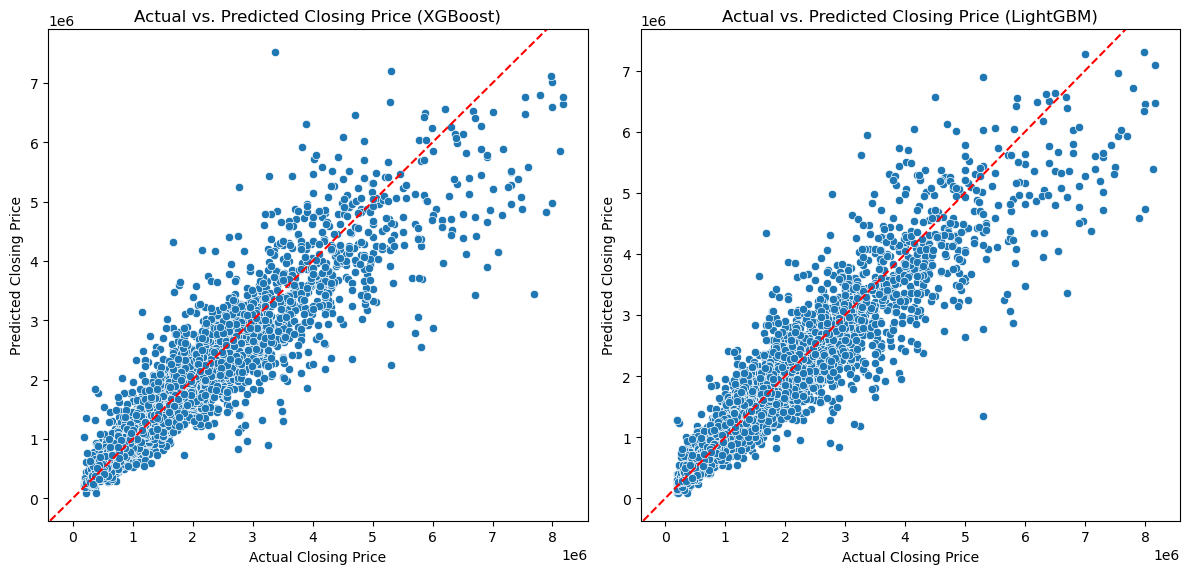

In [71]:
xgb_data = pd.DataFrame({'Actual Closing Price': y_test, 'Predicted Closing Price': xgb_pred})
lgbm_data = pd.DataFrame({'Actual Closing Price': y_test, 'Predicted Closing Price': lgbm_pred})

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(data=xgb_data, x='Actual Closing Price', y='Predicted Closing Price', ax=ax[0])
ax[0].set_title('Actual vs. Predicted Closing Price (XGBoost)')
ax[0].axline((0, 0), slope=1, color='red', linestyle='--', linewidth=1.5)
sns.scatterplot(data=lgbm_data, x='Actual Closing Price', y='Predicted Closing Price', ax=ax[1])
ax[1].set_title('Actual vs. Predicted Closing Price (LightGBM)')
ax[1].axline((0, 0), slope=1, color='red', linestyle='--', linewidth=1.5)
plt.tight_layout()

## Analyze Price Bands

In [57]:
# analyze price bands for linear regression model
lr_df = pd.DataFrame({'Actual': y_test, 'Predicted': lr_pred})

lr_df['PriceBand'] = pd.cut(
    lr_df['Actual'],
    bins=[0, 500_000, 1_000_000, 2_000_000, np.inf],
    labels=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+']
)

lr_band_results = []

for band, group in lr_df.groupby('PriceBand', observed=True):
    m = metrics(group['Actual'], group['Predicted'])
    m['N'] = len(group)
    lr_band_results.append(m)

lr_band_results = pd.DataFrame(lr_band_results, index=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+'])

lr_band_results

,R2,MAE,RMSE,MedianAbsoluteError,MAPE,MDAPE,N
<$500K,-8.1815,$174315.44,$226390.11,$143560.12,46.43%,37.70%,1635
$500K-$1M,-2.6322,$196955.27,$264880.79,$152540.44,27.29%,20.48%,4897
$1M-$2M,-0.4782,$240226.62,$328916.87,$183727.17,17.29%,13.36%,3750
$2M+,0.2905,$706474.87,$993823.51,$503552.51,20.24%,17.39%,1609


In [58]:
# analyze price bands for decision tree model
dt_df = pd.DataFrame({'Actual': y_test, 'Predicted': dt_pred})

dt_df['PriceBand'] = pd.cut(
    dt_df['Actual'],
    bins=[0, 500_000, 1_000_000, 2_000_000, np.inf],
    labels=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+']
)

dt_band_results = []

for band, group in dt_df.groupby('PriceBand', observed=True):
    m = metrics(group['Actual'], group['Predicted'])
    m['N'] = len(group)
    dt_band_results.append(m)

dt_band_results = pd.DataFrame(dt_band_results, index=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+'])

dt_band_results

,R2,MAE,RMSE,MedianAbsoluteError,MAPE,MDAPE,N
<$500K,-3.3249,$70967.01,$155377.94,$40000.00,18.86%,10.34%,1635
$500K-$1M,-0.9597,$101148.66,$194563.35,$63000.00,13.46%,8.57%,4897
$1M-$2M,-1.1036,$249413.68,$392383.85,$169000.00,17.44%,12.46%,3750
$2M+,0.2669,$710464.78,$1010185.82,$500000.00,21.74%,16.85%,1609


In [59]:
# analyze price bands for random forest model
rf_df = pd.DataFrame({'Actual': y_test, 'Predicted': rf_pred})

rf_df['PriceBand'] = pd.cut(
    rf_df['Actual'],
    bins=[0, 500_000, 1_000_000, 2_000_000, np.inf],
    labels=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+']
)

rf_band_results = []

for band, group in rf_df.groupby('PriceBand', observed=True):
    m = metrics(group['Actual'], group['Predicted'])
    m['N'] = len(group)
    rf_band_results.append(m)

rf_band_results = pd.DataFrame(rf_band_results, index=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+'])

rf_band_results

,R2,MAE,RMSE,MedianAbsoluteError,MAPE,MDAPE,N
<$500K,-3.0884,$87531.31,$151070.61,$46761.87,24.04%,12.24%,1635
$500K-$1M,-0.5140,$110782.02,$171013.73,$68840.68,14.97%,9.51%,4897
$1M-$2M,-0.2595,$221416.17,$303610.91,$167762.96,15.58%,12.29%,3750
$2M+,0.4203,$648881.42,$898367.45,$480144.74,19.58%,16.32%,1609


In [60]:
# analyze price bands for XGBoost model
xgb_df = pd.DataFrame({'Actual': y_test, 'Predicted': xgb_pred})

xgb_df['PriceBand'] = pd.cut(
    xgb_df['Actual'],
    bins=[0, 500_000, 1_000_000, 2_000_000, np.inf],
    labels=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+']
)

xgb_band_results = []

for band, group in xgb_df.groupby('PriceBand', observed=True):
    m = metrics(group['Actual'], group['Predicted'])
    m['N'] = len(group)
    xgb_band_results.append(m)

xgb_band_results = pd.DataFrame(xgb_band_results, index=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+'])

xgb_band_results

,R2,MAE,RMSE,MedianAbsoluteError,MAPE,MDAPE,N
<$500K,-1.3233,$60579.73,$113880.86,$36704.19,16.54%,9.27%,1635
$500K-$1M,0.3044,$76449.76,$115914.41,$52142.19,10.28%,7.10%,4897
$1M-$2M,0.1998,$167879.76,$242001.69,$122321.12,11.82%,8.96%,3750
$2M+,0.6241,$505198.88,$723378.64,$358442.00,15.04%,12.28%,1609


In [61]:
# analyze price bands for LightGBM model
lgbm_df = pd.DataFrame({'Actual': y_test, 'Predicted': lgbm_pred})

lgbm_df['PriceBand'] = pd.cut(
    lgbm_df['Actual'],
    bins=[0, 500_000, 1_000_000, 2_000_000, np.inf],
    labels=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+']
)

lgbm_band_results = []

for band, group in lgbm_df.groupby('PriceBand', observed=True):
    m = metrics(group['Actual'], group['Predicted'])
    m['N'] = len(group)
    lgbm_band_results.append(m)

lgbm_band_results = pd.DataFrame(lgbm_band_results, index=['<$500K', '$500K-$1M', '$1M-$2M', '$2M+'])

lgbm_band_results

,R2,MAE,RMSE,MedianAbsoluteError,MAPE,MDAPE,N
<$500K,-0.6813,$59756.78,$96876.69,$38622.81,16.36%,9.66%,1635
$500K-$1M,0.3131,$77496.52,$115192.37,$54179.83,10.41%,7.37%,4897
$1M-$2M,0.2058,$170061.15,$241095.44,$128008.21,11.94%,9.36%,3750
$2M+,0.6526,$494040.95,$695416.48,$351371.91,14.85%,12.34%,1609


## Analyze Price Bands by MdAPE

In [63]:
mdape_results = pd.DataFrame({
    'Linear Regression': lr_band_results['MDAPE'],
    'Decision Tree': dt_band_results['MDAPE'],
    'Random Forest': rf_band_results['MDAPE'],
    'XGBoost': xgb_band_results['MDAPE'],
    'LightGBM': lgbm_band_results['MDAPE']
})

mdape_results

,Linear Regression,Decision Tree,Random Forest,XGBoost,LightGBM
<$500K,37.70%,10.34%,12.24%,9.27%,9.66%
$500K-$1M,20.48%,8.57%,9.51%,7.10%,7.37%
$1M-$2M,13.36%,12.46%,12.29%,8.96%,9.36%
$2M+,17.39%,16.85%,16.32%,12.28%,12.34%
